# Ocean.stats diagnostics (`ocean.stats.nc`)

MOM6 writes a per-timestep integration-diagnostics file, `ocean.stats` (plain text)
and `ocean.stats.nc` (its netCDF equivalent) -- energy, max CFL, mean sea level,
total mass, mean salinity/temperature, and their conservation errors over the
course of the run. This notebook finds `ocean.stats.nc` via the intake-esm
datastore and plots each diagnostic.

See discussion in [access-om3-paper-1#23](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/23)
and [access-nri-intake-catalog#682](https://github.com/ACCESS-NRI/access-nri-intake-catalog/issues/682).

The first draft of thie notebook was written with Claude (prompted by @chrisb13)

In [9]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test4-d28e0359/datastore.json"

# papermill settings. *No need to modify these if running interactively.*
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory
nbname = None                          # notebook name


In [10]:
if not papermill:
    import nci_ipynb, os  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
import mkfigs_bootstrap  # noqa: adds external/access-model-mkfigs/src to sys.path (stop-gap)
from mkfigs import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)


In [11]:
import intake
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np


### Open the intake-esm datastore and find `ocean.stats.nc`

In [12]:
COLUMNS_WITH_ITERABLES = [
    "variable",
    "variable_long_name",
    "variable_standard_name",
    "variable_cell_methods",
    "variable_units",
]

datastore = intake.open_esm_datastore(esm_file, columns_with_iterables=COLUMNS_WITH_ITERABLES)
datastore.search(filename="ocean.stats.nc").df


,filename,path,file_id,frequency,start_date,end_date,variable,variable_long_name,variable_standard_name,variable_cell_methods,variable_units,realm,temporal_label
0,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
1,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
2,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:367,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
3,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
4,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
62,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:367,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
63,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown
64,ocean.stats.nc,/g/data/ol01/outputs/access-om3-25km/MC_25km_j...,ocean.fx.Interface:76.Layer:75.Time:366,fx,none,none,"(APE, En, H0, Heat, Heat_anom, Heat_chg, Inter...","(Total Interface APE, Total Energy, Zero APE D...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(, , , , , , , , , , , , , , , , , , , , , , ,...","(Joules, Joules, meter, Joules, Joules, Joules...",ocean,unknown


### Load `ocean.stats.nc`

Loading `ocean.stats.nc` currently needs two workarounds:

1. The datastore's aggregation only recognises a lowercase `time` dimension when deciding how to join assets, but `ocean.stats.nc` uses `Time`. This means the 66 per-restart `ocean.stats.nc` files aren't concatenated -- they get grouped by `file_id` instead, based on each file's number of timesteps, collapsing everything into just two datasets. `aggregate_on_keys` below removes `file_id` from the aggregation so all matching files are joined into one dataset (see [access-nri-intake-catalog#682](https://github.com/ACCESS-NRI/access-nri-intake-catalog/issues/682) and [this PR discussion](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/pull/137#issuecomment-5673222494) for the full investigation).
2. `Time`'s `units` attribute looks timedelta-like to CF conventions, so xarray tries to decode it as `timedelta64[ns]` -- which overflows for a multi-century run. `decode_times=False` avoids that.

In [13]:
def aggregate_on_keys(ds, keys):
    """Drop `keys` from the datastore's aggregation groupby_attrs so matching
    assets are joined into one dataset instead of being split by those keys
    (workaround for the ocean.stats.nc `Time` vs `time` capitalisation bug --
    see access-nri-intake-catalog#682)."""
    parent_keys = ds.esmcat.aggregation_control.groupby_attrs
    ds.esmcat.aggregation_control.groupby_attrs = [
        key for key in parent_keys if key not in keys
    ]
    return ds


ds_filtered = datastore.search(filename="ocean.stats.nc")
ds_filtered = aggregate_on_keys(ds_filtered, ["file_id"])

ocean_stats = ds_filtered.to_dask(xarray_open_kwargs=dict(decode_times=False))
ocean_stats

<xarray.Dataset> Size: 64MB
Dimensions:         (Time: 24172, Interface: 76, Layer: 75)
Coordinates:
  * Time            (Time) float64 193kB 7.148e+05 7.148e+05 ... 7.389e+05
  * Interface       (Interface) float64 608B 0.0 1.083 2.279 ... 5.61e+03 6e+03
  * Layer           (Layer) float64 600B 0.5413 1.681 ... 5.511e+03 5.805e+03
Data variables: (12/34)
    Ntrunc          (Time) float64 193kB dask.array<chunksize=(366,), meta=np.ndarray>
    En              (Time) float64 193kB dask.array<chunksize=(366,), meta=np.ndarray>
    APE             (Time, Interface) float64 15MB dask.array<chunksize=(366, 76), meta=np.ndarray>
    KE              (Time, Layer) float64 15MB dask.array<chunksize=(366, 75), meta=np.ndarray>
    H0              (Time, Interface) float64 15MB dask.array<chunksize=(366, 76), meta=np.ndarray>
    Mass_lay        (Time, Layer) float64 15MB dask.array<chunksize=(366, 75), meta=np.ndarray>
    ...              ...
    zoo             (Time) float64 193kB dask.array<chunksize=(366,), meta=np.ndarray>
    o2              (Time) float64 193kB dask.array<chunksize=(366,), meta=np.ndarray>
    phyfe           (Time) float64 193kB dask.array<chunksize=(366,), meta=np.ndarray>
    pchl            (Time) float64 193kB dask.array<chunksize=(366,), meta=np.ndarray>
    phy             (Time) float64 193kB dask.array<chunksize=(366,), meta=np.ndarray>
    no3             (Time) float64 193kB dask.array<chunksize=(366,), meta=np.ndarray>
Attributes: (12/15)
    filename:                                 ./ocean.stats.nc
    intake_esm_vars:                          ('APE', 'En', 'H0', 'Heat', 'He...
    intake_esm_attrs:filename:                ocean.stats.nc
    intake_esm_attrs:frequency:               fx
    intake_esm_attrs:start_date:              none
    intake_esm_attrs:end_date:                none
    ...                                       ...
    intake_esm_attrs:variable_cell_methods:   ,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,...
    intake_esm_attrs:variable_units:          Joules,Joules,meter,Joules,Joul...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:temporal_label:          unknown
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   unknown

### Plot each diagnostic over the run

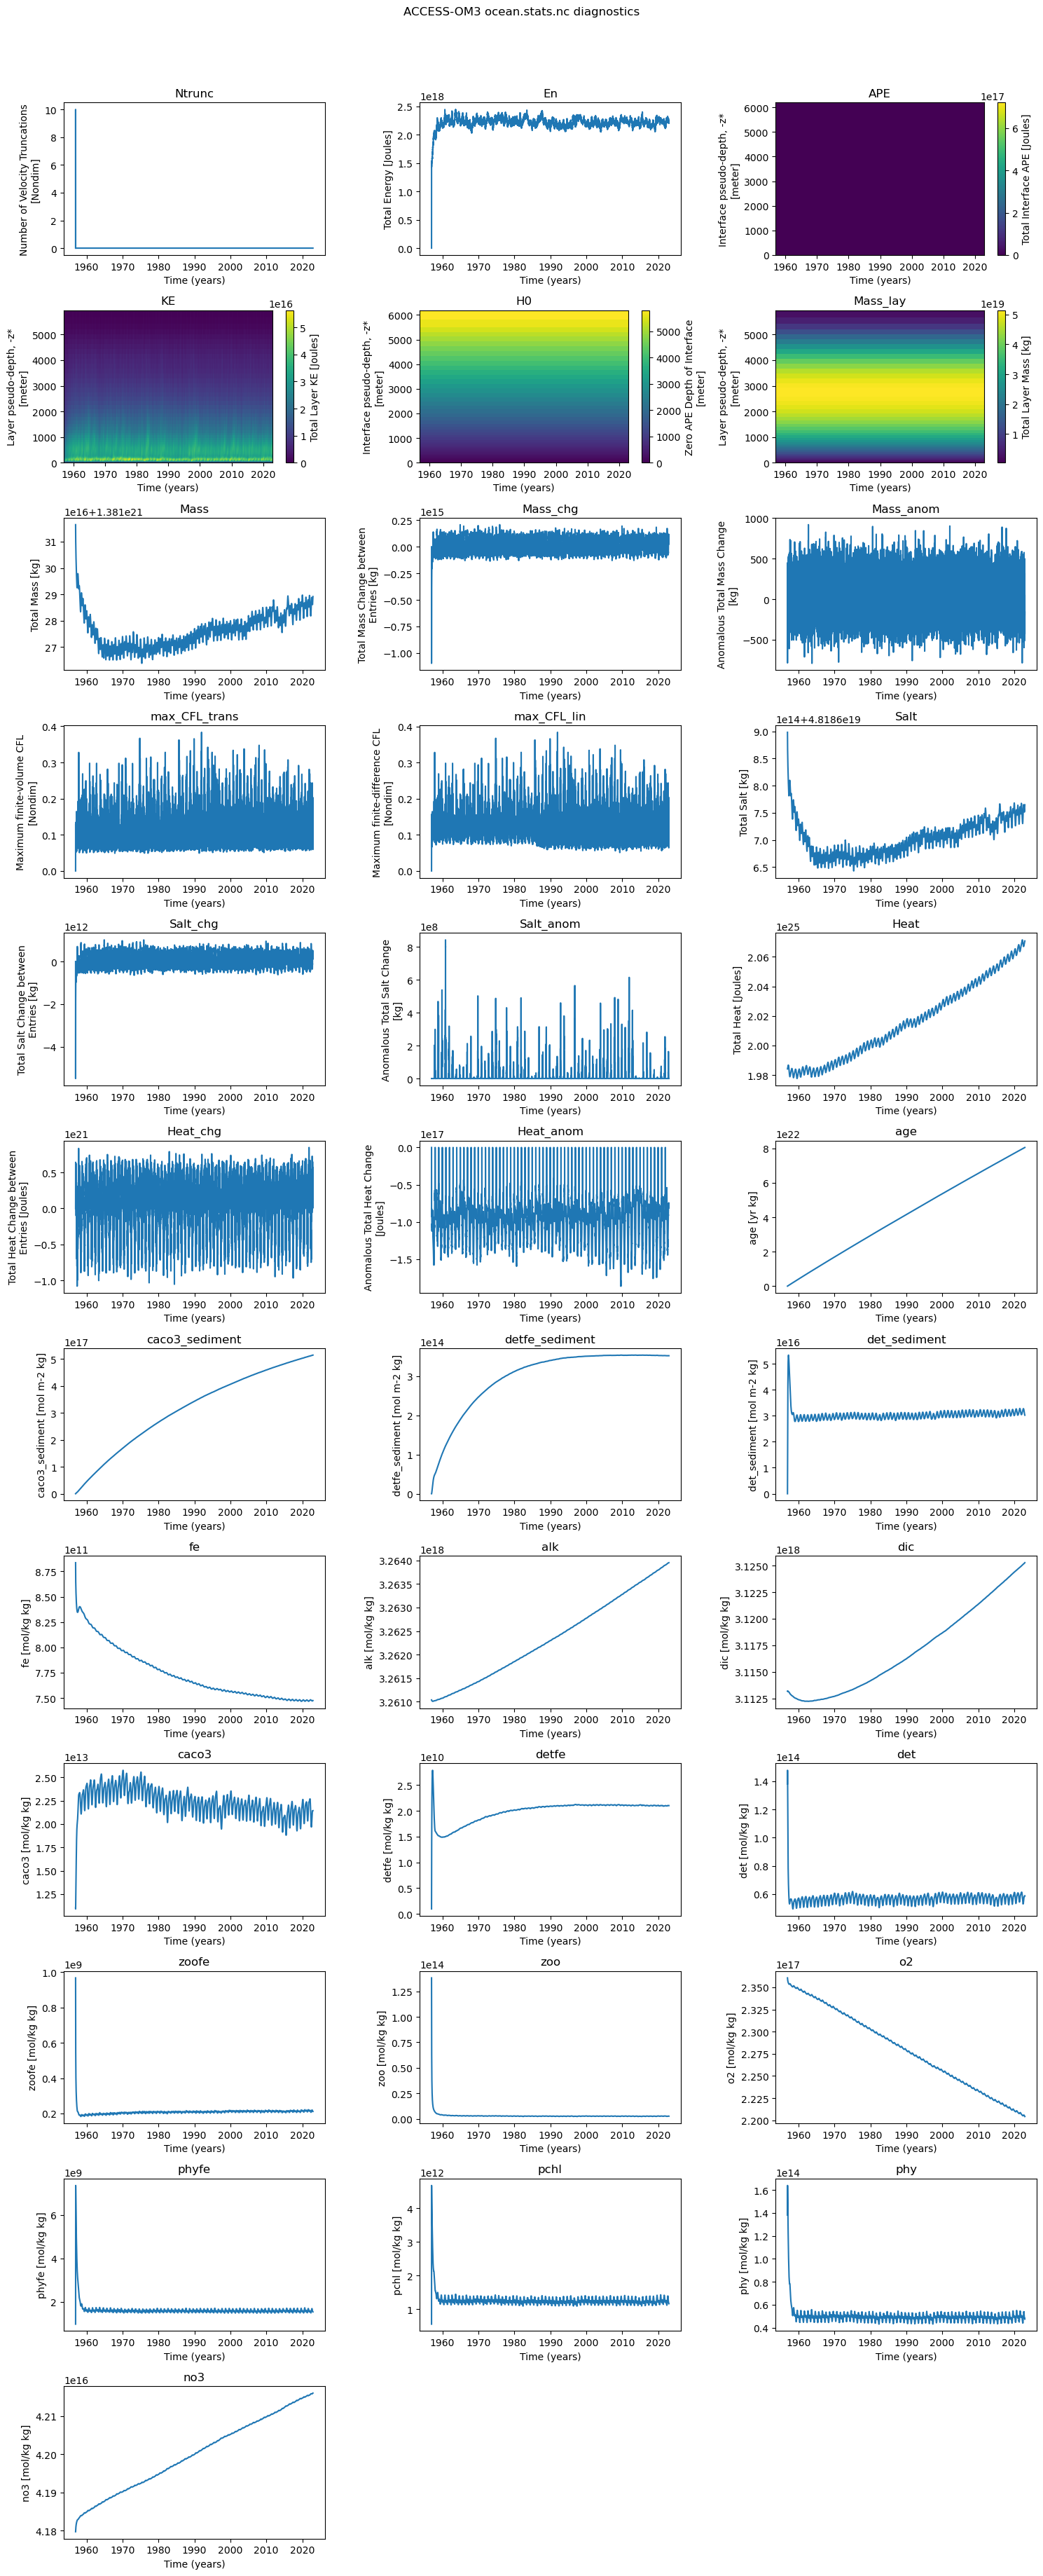

In [14]:
# Time is raw elapsed days (decode_times=False avoids the calendar overflow).
# Convert to years for a more readable axis -- check ocean_stats["Time"].attrs
# for the exact calendar; 365.25 is a reasonable default, use 365 if it's a
# 'noleap' calendar (common for JRA-forced runs).
days_per_year = 365.25
ocean_stats = ocean_stats.assign_coords(Time_years=ocean_stats["Time"] / days_per_year)

data_vars = [v for v in ocean_stats.data_vars if "Time" in ocean_stats[v].dims]

ncols = 3
nrows = -(-len(data_vars) // ncols)  # ceil division
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), squeeze=False)

for ax, var in zip(axes.flat, data_vars):
    ocean_stats[var].plot(ax=ax, x="Time_years")
    ax.set_title(var)
    ax.set_xlabel("Time (years)")

for ax in axes.flat[len(data_vars):]:
    ax.axis("off")

fig.suptitle("ACCESS-OM3 ocean.stats.nc diagnostics", y=1.02)
fig.tight_layout()

In [15]:
# mkmd.savefig(fig, title, caption, dpi=100)
# Save figure and append to markdown summary.
mkmd.savefig(
    fig,
    "Ocean.stats diagnostics",
    "MOM6 integration diagnostics from ocean.stats.nc (energy, max CFL, mean sea "
    "level, total mass, mean salinity/temperature, and their conservation errors) "
    "over the course of the run.",
    dpi=150,
)
